Loading dataset...
Original data shape: (5000, 36)
Selected data shape: (5000, 9)

Preview of selected data:


,Count_subj,rr_interval,p_end,qrs_onset,qrs_end,p_axis,qrs_axis,t_axis,Healthy_Status
0,27,659,128,170,258,81,77,79,0
1,93,722,124,162,246,77,75,70,0
2,3,600,130,162,244,79,72,77,1
3,7,659,146,180,254,79,66,69,1
4,2,659,29999,504,590,84,80,77,0



Cleaning data...
Removed duplicate rows: 2

Target mapping:
  0 -> 0
  1 -> 1

Missing values per column:


,missing_count
Count_subj,0
rr_interval,0
p_end,0
qrs_onset,0
qrs_end,0
p_axis,0
qrs_axis,0
t_axis,0
Healthy_Status,0



Data shape after cleaning: (4998, 9)

Target distribution:


,count
Healthy_Status,
0,4038
1,960



Feature summary:


,count,mean,std,min,25%,50%,75%,max
Count_subj,4998.0,18.196879,24.447909,1.0,4.0,10.0,23.0,260.0
rr_interval,4998.0,857.549420,1183.122315,0.0,674.0,800.0,937.0,29999.0
p_end,4998.0,9346.453381,13783.730800,48.0,144.0,158.0,29999.0,29999.0
qrs_onset,4998.0,284.240096,1118.382319,0.0,188.0,200.0,230.0,29999.0
qrs_end,4998.0,389.229692,1191.138375,139.0,278.0,300.0,345.5,29999.0
p_axis,4998.0,5472.931773,11585.175879,-180.0,38.0,57.0,75.0,32767.0
qrs_axis,4998.0,164.395758,2116.484977,-178.0,-15.0,12.0,46.0,29999.0
t_axis,4998.0,248.780712,2484.830184,-180.0,17.0,45.0,75.0,32767.0



Train shape: (3998, 8)
Test shape : (1000, 8)

Visualization preprocessing completed.
X_train_vis shape: (3998, 8)

Generating PCA plot...


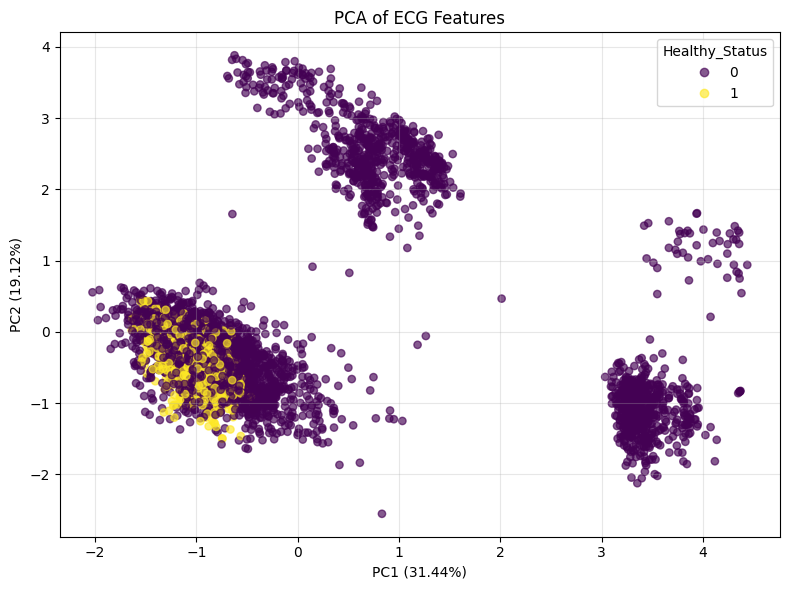

Generating t-SNE plot...


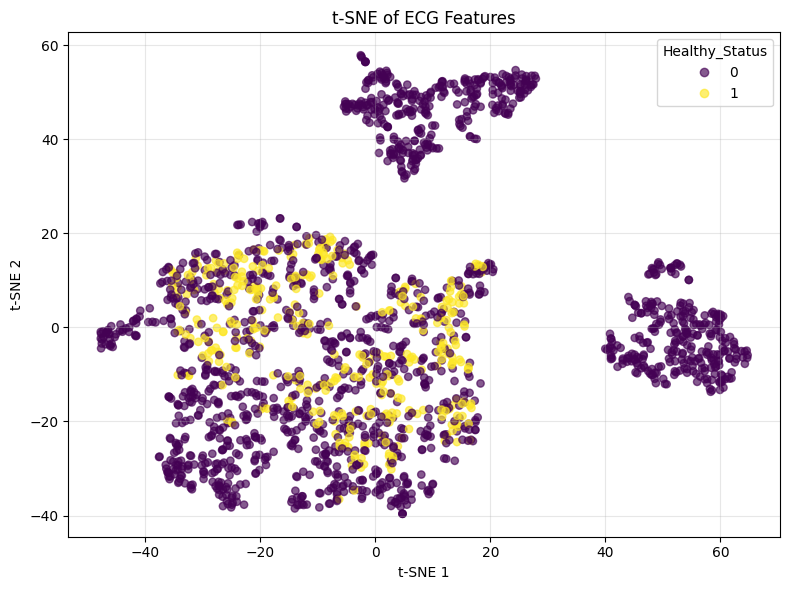


Model preprocessing completed.
X_train_model shape: (3998, 8)
X_test_model shape : (1000, 8)

Sub-train shape: (3198, 8)
Validation shape: (800, 8)

Class distribution after oversampling:


,count
Healthy_Status,
0,2584
1,2584



Training FLAML AutoML...

Best estimator: lgbm
Best config   : {'n_estimators': 196, 'num_leaves': 60, 'min_child_samples': 16, 'learning_rate': 1.0, 'log_max_bin': 9, 'colsample_bytree': 1.0, 'reg_alpha': 0.021120634578611457, 'reg_lambda': 1.642466139365942}

Searching best threshold on validation set...
Best threshold: 0.20
Best validation F1: 0.6220


,threshold,precision,recall,f1
0,0.20,0.586207,0.662338,0.621951
1,0.25,0.583333,0.636364,0.608696
2,0.30,0.594937,0.610390,0.602564
3,0.35,0.588235,0.584416,0.586319
4,0.40,0.586667,0.571429,0.578947
5,0.45,0.597222,0.558442,0.577181
6,0.50,0.598592,0.551948,0.574324
7,0.55,0.592857,0.538961,0.564626
8,0.60,0.597122,0.538961,0.566553
9,0.65,0.591241,0.525974,0.556701



Evaluating on test set...

===== FINAL TEST METRICS =====
Threshold : 0.20
Accuracy  : 0.8530
Precision : 0.5991
Recall    : 0.7083
F1-score  : 0.6492

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0     0.9276    0.8874    0.9070       808
           1     0.5991    0.7083    0.6492       192

    accuracy                         0.8530      1000
   macro avg     0.7633    0.7979    0.7781      1000
weighted avg     0.8645    0.8530    0.8575      1000



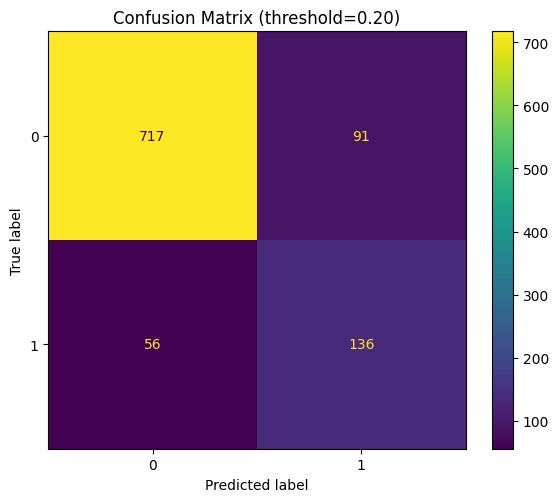


===== FINAL SUMMARY =====
Rows used                  : 4998
Train samples              : 3998
Test samples               : 1000
Best model                 : lgbm
Best threshold             : 0.20
Final F1-score             : 0.6492
Output directory           : C:\Users\lenovo\Desktop\研二\人工系统\ecg_outputs

Saved files:
- cleaned_data.csv
- pca.png
- tsne.png
- confusion_matrix.png
- predictions.csv
- metrics_summary.csv
- threshold_search.csv
- flaml.log


In [1]:
# =========================
# ECG Binary Classification with AutoML
# One-cell Jupyter Notebook Code
# =========================

import sys
import subprocess
import importlib
import warnings
warnings.filterwarnings("ignore")

# ---------- 0. Auto-install required packages ----------
required_packages = [
    ("pandas", "pandas"),
    ("numpy", "numpy"),
    ("matplotlib", "matplotlib"),
    ("sklearn", "scikit-learn"),
    ("flaml", "flaml[automl]"),
    ("imblearn", "imbalanced-learn"),
]

for module_name, package_name in required_packages:
    try:
        importlib.import_module(module_name)
    except ImportError:
        print(f"Installing {package_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

# ---------- 1. Imports ----------
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import RandomOverSampler
from flaml import AutoML

try:
    from IPython.display import display
except ImportError:
    display = print

# ---------- 2. Configuration ----------
DATA_URL = "https://raw.githubusercontent.com/AI-is-out-there/data2lab/refs/heads/main/%D0%BC%D0%BE%D0%B4%D1%83%D0%BB%D1%8C%203%20-%20%D0%B4%D0%B0%D1%82%D0%B0%D1%81%D0%B5%D1%82%20-%20%D0%BF%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0.csv"

N_ROWS = 5000
RANDOM_STATE = 42
TEST_SIZE = 0.20
VAL_SIZE_WITHIN_TRAIN = 0.20
TIME_BUDGET = 180           # seconds; you can increase to 300
TSNE_MAX_SAMPLES = 2000

TARGET = "Healthy_Status"
FEATURES = [
    "Count_subj",
    "rr_interval",
    "p_end",
    "qrs_onset",
    "qrs_end",
    "p_axis",
    "qrs_axis",
    "t_axis"
]

OUTPUT_DIR = Path("ecg_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# ---------- 3. Custom transformer for visualization only ----------
class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper
        self.lower_bounds_ = None
        self.upper_bounds_ = None

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X).copy()
        self.lower_bounds_ = X_df.quantile(self.lower)
        self.upper_bounds_ = X_df.quantile(self.upper)
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        X_clipped = X_df.clip(self.lower_bounds_, self.upper_bounds_, axis=1)
        return X_clipped.values

# ---------- 4. Load dataset ----------
print("Loading dataset...")
df = pd.read_csv(DATA_URL, nrows=N_ROWS)
print(f"Original data shape: {df.shape}")

missing_columns = [col for col in FEATURES + [TARGET] if col not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns in dataset: {missing_columns}")

data = df[FEATURES + [TARGET]].copy()
print(f"Selected data shape: {data.shape}")

print("\nPreview of selected data:")
display(data.head())

# ---------- 5. Data cleaning ----------
print("\nCleaning data...")

# Convert feature columns to numeric
for col in FEATURES:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Keep target as string first, then encode later
data[TARGET] = data[TARGET].astype(str)

# Drop duplicate rows
before_dedup = len(data)
data = data.drop_duplicates().reset_index(drop=True)
after_dedup = len(data)

# Drop missing target
data = data.dropna(subset=[TARGET]).copy()

# Replace obvious target missing strings if any
data = data[~data[TARGET].str.lower().isin(["nan", "none", "", "missing"])].copy()

# Encode target
label_encoder = LabelEncoder()
data[TARGET] = label_encoder.fit_transform(data[TARGET])

if len(label_encoder.classes_) != 2:
    raise ValueError(
        f"Target column '{TARGET}' is not binary after encoding. Classes found: {list(label_encoder.classes_)}"
    )

print(f"Removed duplicate rows: {before_dedup - after_dedup}")

print("\nTarget mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {cls} -> {i}")

print("\nMissing values per column:")
display(data.isna().sum().to_frame("missing_count"))

print("\nData shape after cleaning:", data.shape)

print("\nTarget distribution:")
display(data[TARGET].value_counts().sort_index().to_frame("count"))

print("\nFeature summary:")
display(data[FEATURES].describe().T)

# ---------- 6. Train / Test split ----------
X = data[FEATURES].copy()
y = data[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"\nTrain shape: {X_train.shape}")
print(f"Test shape : {X_test.shape}")

# ---------- 7. Visualization preprocessing ----------
# Keep clipper here to make PCA/t-SNE more stable
preprocessor_vis = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clipper", QuantileClipper(lower=0.01, upper=0.99)),
    ("scaler", StandardScaler())
])

X_train_vis = preprocessor_vis.fit_transform(X_train)
X_test_vis = preprocessor_vis.transform(X_test)

print("\nVisualization preprocessing completed.")
print("X_train_vis shape:", X_train_vis.shape)

# ---------- 8. PCA Visualization ----------
print("\nGenerating PCA plot...")

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_vis)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train,
    alpha=0.65,
    s=28
)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
plt.title("PCA of ECG Features")
plt.legend(*scatter.legend_elements(), title=TARGET)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pca.png", dpi=200)
plt.show()

# ---------- 9. t-SNE Visualization ----------
print("Generating t-SNE plot...")

rng = np.random.default_rng(RANDOM_STATE)

if len(X_train_vis) > TSNE_MAX_SAMPLES:
    idx = rng.choice(len(X_train_vis), size=TSNE_MAX_SAMPLES, replace=False)
    X_tsne_input = X_train_vis[idx]
    y_tsne = y_train.iloc[idx].reset_index(drop=True)
else:
    X_tsne_input = X_train_vis
    y_tsne = y_train.reset_index(drop=True)

perplexity = min(30, max(5, len(X_tsne_input) // 10))

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE
)

X_train_tsne = tsne.fit_transform(X_tsne_input)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_train_tsne[:, 0],
    X_train_tsne[:, 1],
    c=y_tsne,
    alpha=0.65,
    s=28
)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE of ECG Features")
plt.legend(*scatter.legend_elements(), title=TARGET)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "tsne.png", dpi=200)
plt.show()

# ---------- 10. Model preprocessing ----------
# Do NOT use clipper here, to preserve potentially useful minority-class information
preprocessor_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_train_model = preprocessor_model.fit_transform(X_train)
X_test_model = preprocessor_model.transform(X_test)

print("\nModel preprocessing completed.")
print("X_train_model shape:", X_train_model.shape)
print("X_test_model shape :", X_test_model.shape)

# ---------- 11. Split train into sub-train and validation ----------
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_model,
    y_train,
    test_size=VAL_SIZE_WITHIN_TRAIN,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("\nSub-train shape:", X_train_sub.shape)
print("Validation shape:", X_val.shape)

# ---------- 12. Oversample minority class on sub-train only ----------
ros = RandomOverSampler(random_state=RANDOM_STATE)
X_train_sub_res, y_train_sub_res = ros.fit_resample(X_train_sub, y_train_sub)

print("\nClass distribution after oversampling:")
display(pd.Series(y_train_sub_res).value_counts().sort_index().to_frame("count"))

# ---------- 13. Train AutoML model ----------
print("\nTraining FLAML AutoML...")

automl = AutoML()
automl_settings = {
    "time_budget": TIME_BUDGET,
    "metric": "f1",
    "task": "classification",
    "eval_method": "cv",
    "n_splits": 5,
    "seed": RANDOM_STATE,
    "verbose": 1,
    "log_file_name": str(OUTPUT_DIR / "flaml.log")
}

automl.fit(
    X_train=X_train_sub_res,
    y_train=y_train_sub_res,
    **automl_settings
)

print("\nBest estimator:", automl.best_estimator)
print("Best config   :", automl.best_config)

# ---------- 14. Threshold tuning on validation set ----------
print("\nSearching best threshold on validation set...")

val_proba = automl.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.20, 0.81, 0.05)
best_threshold = 0.50
best_val_f1 = -1
threshold_results = []

for th in thresholds:
    y_val_pred = (val_proba >= th).astype(int)
    val_prec = precision_score(y_val, y_val_pred, zero_division=0)
    val_rec = recall_score(y_val, y_val_pred, zero_division=0)
    val_f1 = f1_score(y_val, y_val_pred, zero_division=0)

    threshold_results.append({
        "threshold": round(float(th), 2),
        "precision": float(val_prec),
        "recall": float(val_rec),
        "f1": float(val_f1)
    })

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_threshold = th

threshold_df = pd.DataFrame(threshold_results)

print(f"Best threshold: {best_threshold:.2f}")
print(f"Best validation F1: {best_val_f1:.4f}")

display(threshold_df)

# ---------- 15. Final prediction on test set ----------
print("\nEvaluating on test set...")

test_proba = automl.predict_proba(X_test_model)[:, 1]
y_pred = (test_proba >= best_threshold).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("\n===== FINAL TEST METRICS =====")
print(f"Threshold : {best_threshold:.2f}")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

# ---------- 16. Confusion Matrix ----------
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d", ax=ax)
plt.title(f"Confusion Matrix (threshold={best_threshold:.2f})")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=200)
plt.show()

# ---------- 17. Save results ----------
predictions_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_pred,
    "prob_class_1": test_proba
})

metrics_df = pd.DataFrame({
    "metric": [
        "accuracy", "precision", "recall", "f1_score",
        "threshold", "tn", "fp", "fn", "tp"
    ],
    "value": [
        acc, prec, rec, f1,
        best_threshold, cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
    ]
})

data.to_csv(OUTPUT_DIR / "cleaned_data.csv", index=False)
predictions_df.to_csv(OUTPUT_DIR / "predictions.csv", index=False)
metrics_df.to_csv(OUTPUT_DIR / "metrics_summary.csv", index=False)
threshold_df.to_csv(OUTPUT_DIR / "threshold_search.csv", index=False)

# ---------- 18. Final summary ----------
print("\n===== FINAL SUMMARY =====")
print(f"Rows used                  : {len(data)}")
print(f"Train samples              : {len(X_train)}")
print(f"Test samples               : {len(X_test)}")
print(f"Best model                 : {automl.best_estimator}")
print(f"Best threshold             : {best_threshold:.2f}")
print(f"Final F1-score             : {f1:.4f}")
print(f"Output directory           : {OUTPUT_DIR.resolve()}")

print("\nSaved files:")
for file_name in [
    "cleaned_data.csv",
    "pca.png",
    "tsne.png",
    "confusion_matrix.png",
    "predictions.csv",
    "metrics_summary.csv",
    "threshold_search.csv",
    "flaml.log"
]:
    print("-", file_name)